In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report)

In [211]:
data = pd.read_csv('D:\Khushan_BDA\APS\Telco-Custumer-Churn\data\Telco-Customer-Churn.csv')

<>:1: SyntaxWarning: "\K" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\K"? A raw string is also an option.
<>:1: SyntaxWarning: "\K" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\K"? A raw string is also an option.
C:\Users\MSIS\AppData\Local\Temp\ipykernel_6116\1195985081.py:1: SyntaxWarning: "\K" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\K"? A raw string is also an option.
  data = pd.read_csv('D:\Khushan_BDA\APS\Telco-Custumer-Churn\data\Telco-Customer-Churn.csv')


In [212]:
print(data.shape)

(7043, 21)


In [213]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [214]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [215]:
print(data.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [216]:
print(data.isnull().sum().sum()) #for total null values in whole dataset

11


In [217]:
#to convert null values into NAN
pd.to_numeric(data["TotalCharges"],errors="coerce")

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [218]:
# Handle missing values

data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())



In [219]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [220]:
print(data.isnull().sum().sum())

0


In [221]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [222]:
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [223]:
data["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [224]:
data["Churn"] = data["Churn"].map({"No": 0,"Yes": 1})

In [225]:
data["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [226]:
# Create class distribution table

class_counts = data["Churn"].value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class": ["No Churn", "Churn"],
    "count": class_counts.values,
    "Probability": class_counts.values / len(data)
})

print(class_distribution)

      class  count  Probability
0  No Churn   5174      0.73463
1     Churn   1869      0.26537


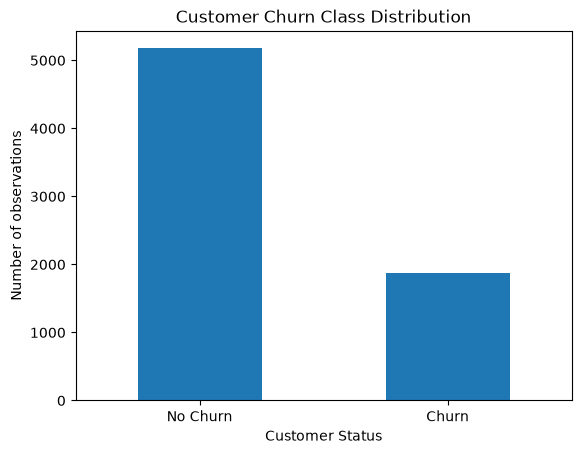

In [227]:
class_distribution.plot(
    x="class",
    y="count",
    kind="bar",
    legend=False
)

plt.ylabel("Number of observations")
plt.xlabel("Customer Status")
plt.title("Customer Churn Class Distribution")
plt.xticks(rotation=0)
plt.show()

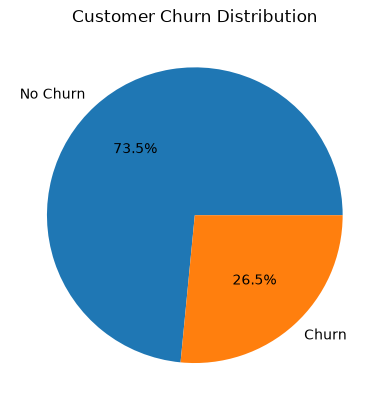

In [228]:
class_distribution.plot(
    x="class",
    y="count",
    kind="pie",
    labels=class_distribution["class"],
    autopct="%1.1f%%",
    legend=False
)

plt.ylabel("")
plt.title("Customer Churn Distribution")
plt.show()

In [229]:
X = data.drop(
    columns=["Churn", "customerID"]
)

y = data["Churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 19)
Target shape: (7043,)


In [230]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical Features:")
print(numerical_features.tolist())

print("\nCategorical Features:")
print(categorical_features.tolist())

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\MSIS\AppData\Local\Temp\ipykernel_6116\3862031886.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [231]:
# One-hot encode categorical variables

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

print("Feature shape after encoding:", X.shape)

X.head()

Feature shape after encoding: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [232]:
print("Null values in X:")
print(X.isnull().sum().sum())

print("\nNull values in y:")
print(y.isnull().sum())

Null values in X:
0

Null values in y:
0


In [234]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [235]:
print("\nTraining Proportions:")
print(
    y_train.value_counts(normalize=True)
    .sort_index()
)

print("\nTesting Proportions:")
print(
    y_test.value_counts(normalize=True)
    .sort_index()
)


Training Proportions:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing Proportions:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [236]:
model = Pipeline([("scaler", StandardScaler()),("logistic", LogisticRegression(max_iter=1000))])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['SeniorCitizen','tenure','MonthlyCharges',..., 'PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [238]:
y_pred = model.predict(X_test)

In [ ]:
probabilities = model.predict_proba(X_test)
print("First 5 probability predictions:")
print(probabilities[:5])

First 5 probability predictions:
[[0.95563487 0.04436513]
 [0.31639994 0.68360006]
 [0.94356046 0.05643954]
 [0.59169375 0.40830625]
 [0.97830853 0.02169147]]


In [240]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "P_No_Churn": probabilities[:, 0],
    "P_Churn": probabilities[:, 1]
})

results.head(10)

,Actual,P_No_Churn,P_Churn
0,0,0.955635,0.044365
1,0,0.316400,0.683600
2,0,0.943560,0.056440
3,0,0.591694,0.408306
4,0,0.978309,0.021691
5,0,0.395634,0.604366
6,0,0.547279,0.452721
7,0,0.868793,0.131207
8,0,0.997092,0.002908
9,1,0.605752,0.394248


In [241]:
results["Actual_label"] = results["Actual"].map({
    0: "No Churn",
    1: "Churn"
})

results["Predicted"] = y_pred

results["Predicted_label"] = results["Predicted"].map({
    0: "No Churn",
    1: "Churn"
})

results.head(10)

,Actual,P_No_Churn,P_Churn,Actual_label,Predicted,Predicted_label
0,0,0.955635,0.044365,No Churn,0,No Churn
1,0,0.316400,0.683600,No Churn,1,Churn
2,0,0.943560,0.056440,No Churn,0,No Churn
3,0,0.591694,0.408306,No Churn,0,No Churn
4,0,0.978309,0.021691,No Churn,0,No Churn
5,0,0.395634,0.604366,No Churn,1,Churn
6,0,0.547279,0.452721,No Churn,0,No Churn
7,0,0.868793,0.131207,No Churn,0,No Churn
8,0,0.997092,0.002908,No Churn,0,No Churn
9,1,0.605752,0.394248,Churn,0,No Churn


In [242]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8069552874378992
Accuracy (%): 80.69552874378992


In [243]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[925 110]
 [162 212]]


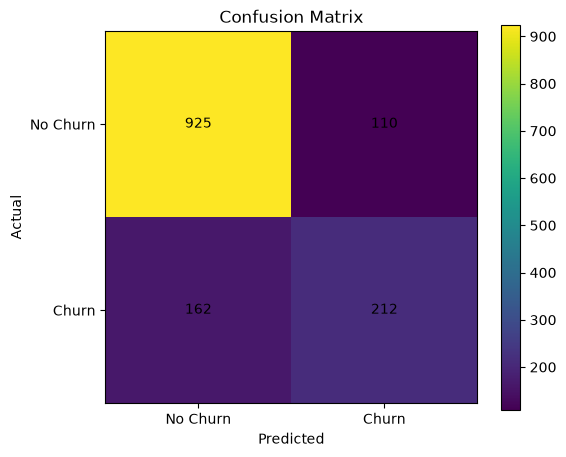

In [244]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.yticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [245]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1 Score: 0.6091954022988506


In [246]:
thresholds = [0.10, 0.30, 0.50, 0.70, 0.90]
metrics_data = []

for threshold in thresholds:

    predicted_churn = (
        probabilities[:, 1] >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        predicted_churn,
        labels=[0, 1]
    )

    TN, FP, FN, TP = cm.ravel()

    metrics_data.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            predicted_churn
        ),
        "Precision": precision_score(
            y_test,
            predicted_churn,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predicted_churn,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            predicted_churn,
            zero_division=0
        ),
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP
    })

threshold_metrics = pd.DataFrame(metrics_data)

threshold_metrics.round(3)

,Threshold,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
0,0.1,0.618,0.406,0.947,0.568,517,518,20,354
1,0.3,0.749,0.518,0.754,0.614,773,262,92,282
2,0.5,0.807,0.658,0.567,0.609,925,110,162,212
3,0.7,0.764,0.730,0.174,0.281,1011,24,309,65
4,0.9,0.735,0.000,0.000,0.000,1035,0,374,0


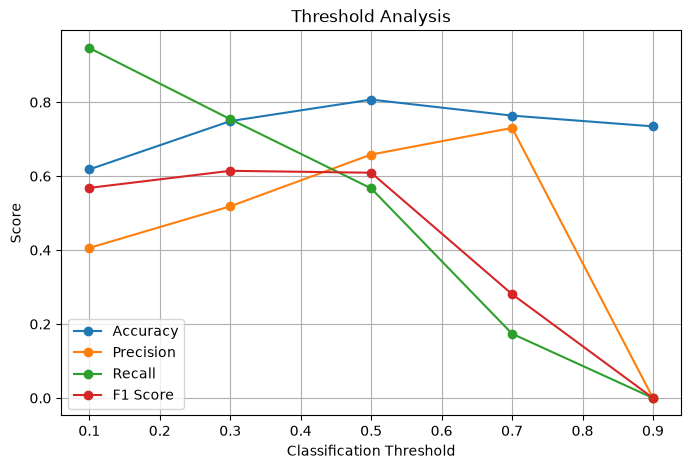

In [247]:
# Plot threshold performance

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_metrics["Threshold"],
    threshold_metrics["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    threshold_metrics["Threshold"],
    threshold_metrics["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_metrics["Threshold"],
    threshold_metrics["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_metrics["Threshold"],
    threshold_metrics["F1-score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.grid(True)

plt.show()